# Web Scraping Demo

In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup # this lib is used for web scraping

In [5]:
headers={'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) Apple WeKit /537.36(KHTML , like Gecko) Chrome/80.0.3987.162 Safari/537.36'} 

webpage = requests.get('https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav',headers=headers).text

In [6]:
soup = BeautifulSoup(webpage, 'lxml')

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script defer="" src="/static/js/env-runtime.js">
  </script>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Top Companies in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-head="ssr" name="revisit-a
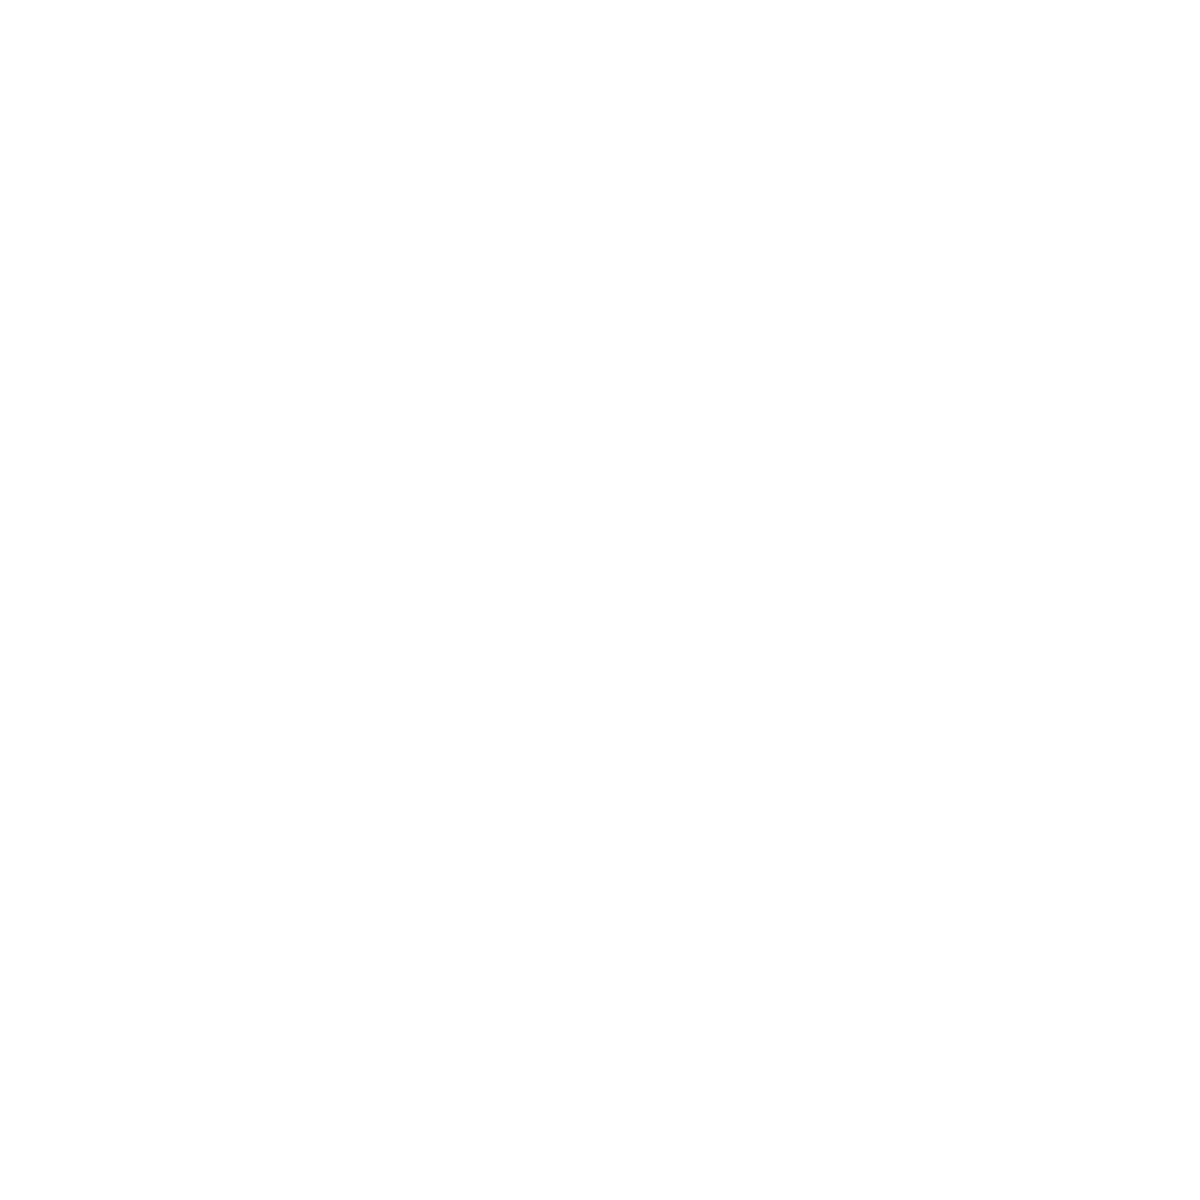

In [7]:
print(soup.prettify())

In [8]:
for i in soup.find_all('h2'):
    print(i.text.strip())

Companies in India
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Axis Bank
Jio
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTM Limited
HDB Financial Services
Popular Collections by Industries
Popular Collections by Cities
Popular Collections by Roles


In [11]:
company = soup.find_all('div', class_= 'companyCardWrapper__primaryInformation')
len(company)

20

In [45]:
name = []
rating = []
jobPost = []
jobSecurity = []

for i in company: 
    name.append(i.find('h2').text.strip())

    ratings = i.find_all('span', class_='companyCardWrapper__companyRatingCount')
    if ratings:
        rating.append(ratings[0].text.strip())

    jobPosts = i.find('span', class_='companyCardWrapper__interLinking')
    if jobPosts:
        jobPost.append(jobPosts.text.strip())

    jobSecuritys = i.find('span', class_='companyCardWrapper__ratingValues')
    if jobSecuritys:
        jobSecurity.append(jobSecuritys.text.strip())


dataset=pd.DataFrame({'Name': name, 'Rating': rating, 'Job_Post': jobPost, 'Job_Security': jobSecurity }
)
dataset
 

,Name,Rating,Job_Post,Job_Security
0,TCS,(1.2L),IT Services & Consulting | Bengaluru +448 othe...,Job Security
1,Accenture,(75.3k),IT Services & Consulting | Bengaluru +261 othe...,"Promotions, Salary, Work Satisfaction"
2,Wipro,(66.5k),IT Services & Consulting | Hyderabad +375 othe...,"Promotions, Salary, Work Satisfaction"
3,Cognizant,(62.7k),IT Services & Consulting | Hyderabad +233 othe...,"Promotions, Salary, Work Satisfaction"
4,Capgemini,(54.8k),IT Services & Consulting | Bengaluru +188 othe...,"Work Life Balance, Job Security"
5,HDFC Bank,(53.9k),Banking | Mumbai +1866 other locations,"Job Security, Skill Development"
6,Infosys,(50k),IT Services & Consulting | Bengaluru +247 othe...,Job Security
7,HCLTech,(47.1k),IT Services & Consulting | Chennai +232 other ...,"Promotions, Salary, Work Satisfaction"
8,ICICI Bank,(46.8k),Banking | Mumbai +1452 other locations,"Job Security, Promotions, Skill Development"
9,Tech Mahindra,(44.3k),IT Services & Consulting | Hyderabad +323 othe...,"Promotions, Salary, Work Satisfaction"


In [ ]:
print("Name:", len(name))
print("Rating:", len(rating))
print("Job_Post:", len(jobPost))

print("Job_Security:", len(jobSecurity))

Name: 20
Rating: 20
Job_Post: 20
Job_Rate: 12
Job_Security: 20
